In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/content/drive/MyDrive/Netflix Analysis project/Netflix Data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# View basic structure
print(df.shape)
print(df.columns)
df.head()



(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Count missing values in each column
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


# ✅ Step 3: Clean Missing Data

In [ ]:
# # 1

# # Fill missing categorical fields with placeholder values
# df['director'] = df['director'].fillna('No Director')
# df['cast'] = df['cast'].fillna('No Cast')
# df['country'] = df['country'].fillna('Unknown')
# df['rating'] = df['rating'].fillna('Not Rated')

# # Convert date_added to datetime and extract useful parts
# df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# df['year_added'] = df['date_added'].dt.year
# df['month_added'] = df['date_added'].dt.month

# # Number of actors listed
# df['num_cast'] = df['cast'].apply(lambda x: len(str(x).split(',')))

Missing values after cleaning:
show_id              0
type                 0
title                0
director             0
cast                 0
country              0
date_added           0
release_year         0
rating               0
duration             0
listed_in            0
description          0
year_added           0
month_added          0
type_encoded         0
num_cast             0
duration_minutes     3
length_category     22
num_genres           0
multi_country        0
dtype: int64


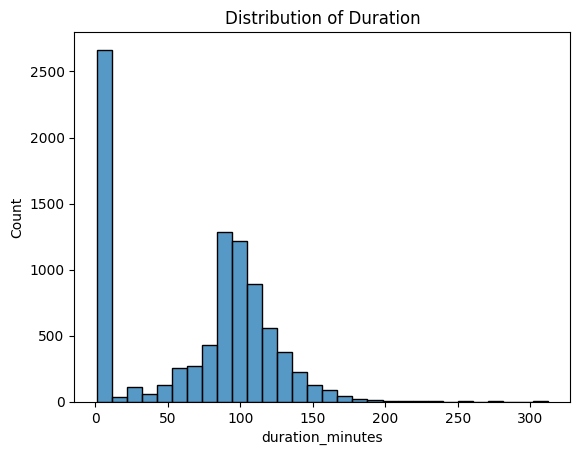

In [4]:
#2

import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Netflix Analysis project/Netflix Data/netflix_titles.csv')

# ----------------------------------------
# STEP 1: Basic Cleaning - Trim and Convert 'date_added'
# ----------------------------------------

# Convert to string and strip whitespaces
df['date_added'] = df['date_added'].astype(str).str.strip()

# Convert to datetime, coerce errors to NaT
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Drop rows where conversion failed (optional but cleaner)
df = df[df['date_added'].notna()]

# Extract year and month added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# ----------------------------------------
# STEP 2: Handle Missing Values
# ----------------------------------------

df['director'] = df['director'].fillna('No Director')
df['cast'] = df['cast'].fillna('No Cast')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown Duration')

# ----------------------------------------
# STEP 3: Handle Duplicates
# ----------------------------------------

df = df.drop_duplicates()

# ----------------------------------------
# STEP 4: Feature Engineering
# ----------------------------------------

# Encode type as numeric
df['type_encoded'] = df['type'].map({'Movie': 0, 'TV Show': 1})

# Number of cast members
df['num_cast'] = df['cast'].apply(lambda x: len(str(x).split(',')) if x != 'No Cast' else 0)

# Duration in minutes (extract numeric part)
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)')
df['duration_minutes'] = pd.to_numeric(df['duration_minutes'], errors='coerce')

# Content length category
df['length_category'] = pd.cut(df['duration_minutes'],
                               bins=[0, 60, 90, 200],
                               labels=['Short', 'Medium', 'Long'])

# Number of genres listed
df['num_genres'] = df['listed_in'].apply(lambda x: len(str(x).split(',')))

# Multi-country flag
df['multi_country'] = df['country'].apply(lambda x: 1 if ',' in x else 0)

# ----------------------------------------
# OPTIONAL: Recheck for missing values
# ----------------------------------------

print("Missing values after cleaning:")
print(df.isnull().sum())


#_______________________________________________________________

# 1. Normalize Text Columns
# Standardize title and listed_in columns
df['title'] = df['title'].str.strip().str.title()
df['listed_in'] = df['listed_in'].str.strip().str.title()

# 2. Extract More Date Features
df['weekday_added'] = df['date_added'].dt.day_name()


# One-hot encode genres
genres = df['listed_in'].str.get_dummies(sep=', ')
df = pd.concat([df, genres], axis=1)


# 3. Genre Standardization or Tag Exploding
# One-hot encode genres
genres = df['listed_in'].str.get_dummies(sep=', ')
df = pd.concat([df, genres], axis=1)


# 4. Country Feature Enhancements
# Extract primary country
df['main_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())

# Optionally: label encoding for modeling
le = LabelEncoder()
df['main_country_encoded'] = le.fit_transform(df['main_country'])

# Added a 'Decade' Column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'


#visual checks
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of duration
sns.histplot(df['duration_minutes'].dropna(), bins=30)
plt.title('Distribution of Duration')
plt.show()


In [ ]:
-# # If using machine learning later
# df['type'] = df['type'].map({'Movie': 0, 'TV Show': 1})
# df = pd.get_dummies(df, columns=['rating'], drop_first=True)


In [ ]:
# df = df.drop_duplicates()
# df = df.drop(columns=['show_id', 'description'])  # drop if not needed


In [ ]:
# Check number of cast members
# df['num_cast'].describe()
# # You can remove entries with extremely high number of cast
# df = df[df['num_cast'] < 20]


# 🔹 Step 8: Exploratory Data Analysis (Optional)

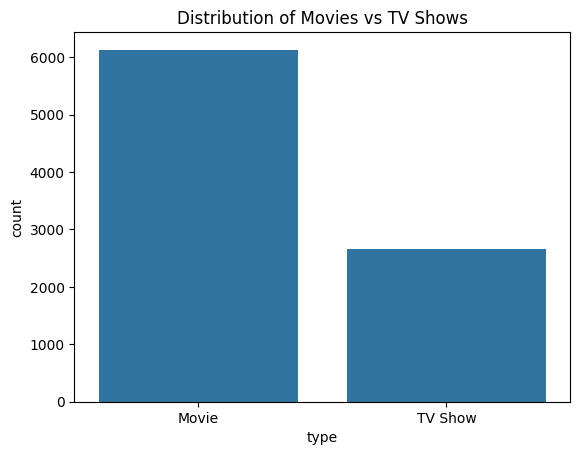

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)
plt.title('Distribution of Movies vs TV Shows')
plt.show()


# # Distribution of content type
# plt.figure(figsize=(6,4))
# sns.countplot(x='type', data=df)
# plt.title('Distribution of Content Type on Netflix')
# plt.xlabel('Content Type')
# plt.ylabel('Count')
# plt.show()

# # Top 10 countries
# plt.figure(figsize=(8,5))
# df['country'].value_counts().head(10).plot(kind='barh')
# plt.title('Top 10 Content Producing Countries on Netflix')
# plt.xlabel('Number of Titles')
# plt.ylabel('Country')
# plt.show()


In [13]:
# ✅ 3. Splitting the Data
# Prepare your data for modeling by splitting into train and test sets.

from sklearn.model_selection import train_test_split

X = df[['num_cast', 'duration_minutes', 'multi_country']]  # example features
y = df['type_encoded']  # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Handle missing values in X
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Encode target safely
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# One-hot encode features
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 0.9982954545454545


# Analysis

1. What types of content does Netflix release over time?

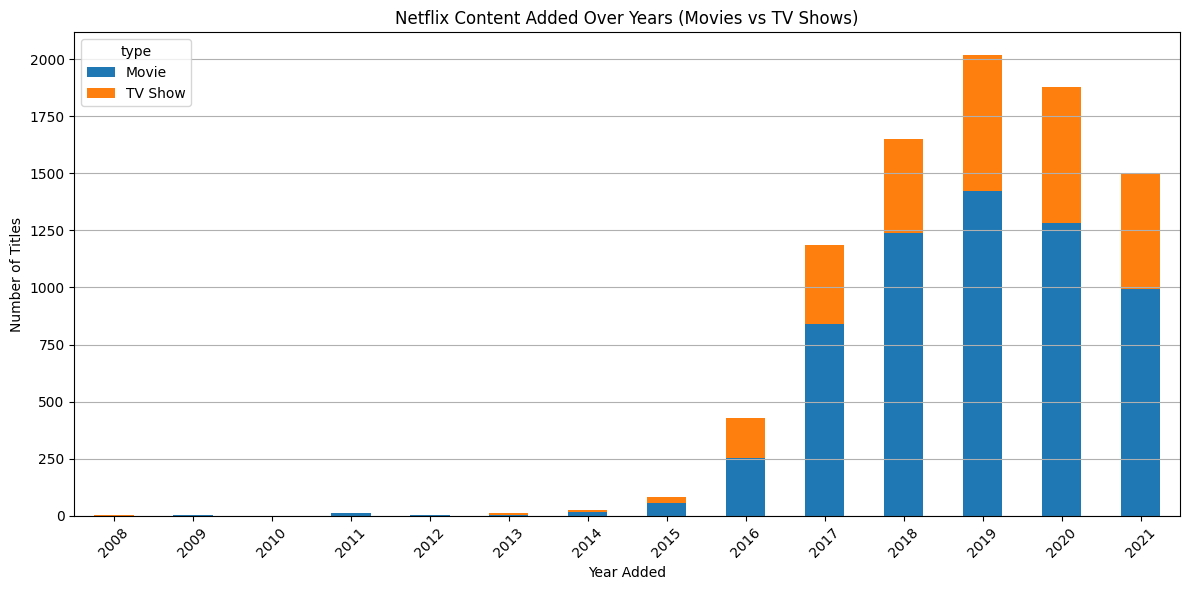

In [15]:
import matplotlib.pyplot as plt

# Group by year and type, count entries
content_over_time = df.groupby(['year_added', 'type']).size().unstack()

# Plot
content_over_time.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Netflix Content Added Over Years (Movies vs TV Shows)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


🌍 2. Top producing countries

/tmp/ipython-input-4285934581.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


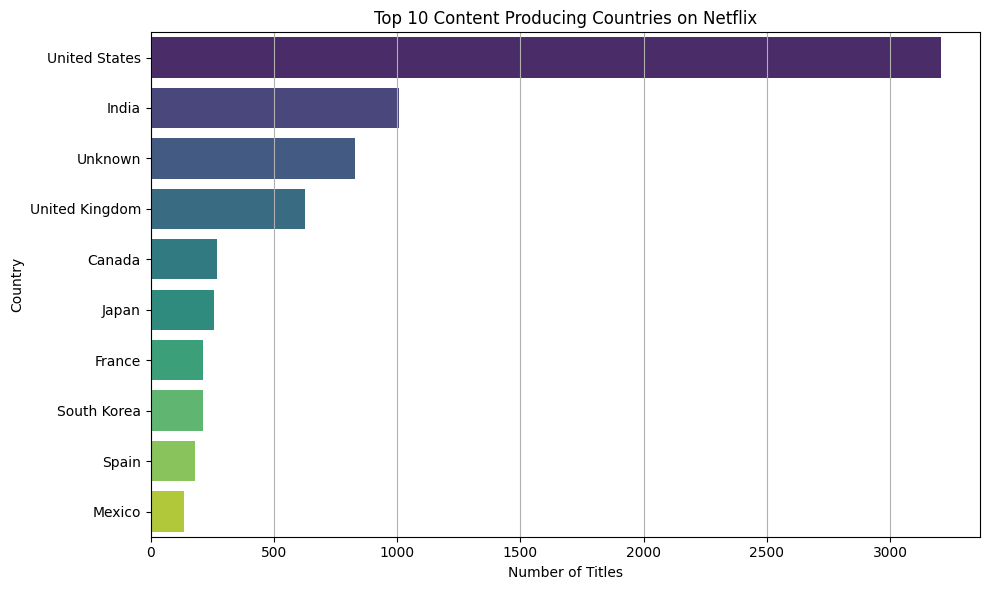

In [16]:
import seaborn as sns

# Extract the primary country (first in the list)
df['main_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())

# Count and plot top 10 countries
top_countries = df['main_country'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


🎭 3. What are the most common genres on Netflix?

/tmp/ipython-input-3811012733.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='rocket')


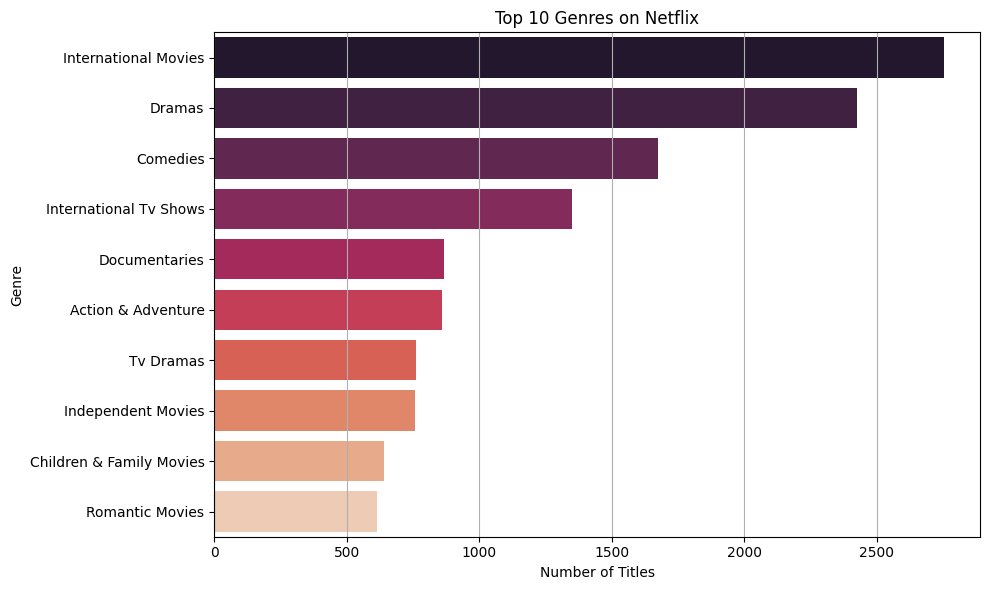

In [17]:
from collections import Counter

# Create a Counter to count genres
genre_counter = Counter()

# Go through each listed_in value and update the counter
df['listed_in'].dropna().str.split(', ').apply(genre_counter.update)

# Convert to Series and get top 10 genres
top_genres = pd.Series(genre_counter).sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='rocket')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


⏱ 4. How long are Netflix movies on average?

Mean: 99.57718668407311
Median: 98.0
Max: 312.0
Min: 3.0
📊 Average movie length: 99.6 minutes
🧾 Unusually short: < 43.0 minutes
🧾 Unusually long: > 156.2 minutes

🎬 Movies with unusual durations:

                                                 title  duration_minutes
3777                                            Silent               3.0
2713                                       Sol Levante               5.0
1484                                  Cops And Robbers               8.0
1557                                            Canvas               9.0
3535  American Factory: A Conversation With The Obamas              10.0
...                                                ...               ...
2484                                Lock Your Girls In             233.0
2487                                    No Longer Kids             237.0
2491                            The School Of Mischief             253.0
717                        Headspace: Unwind Your Mind             273.0


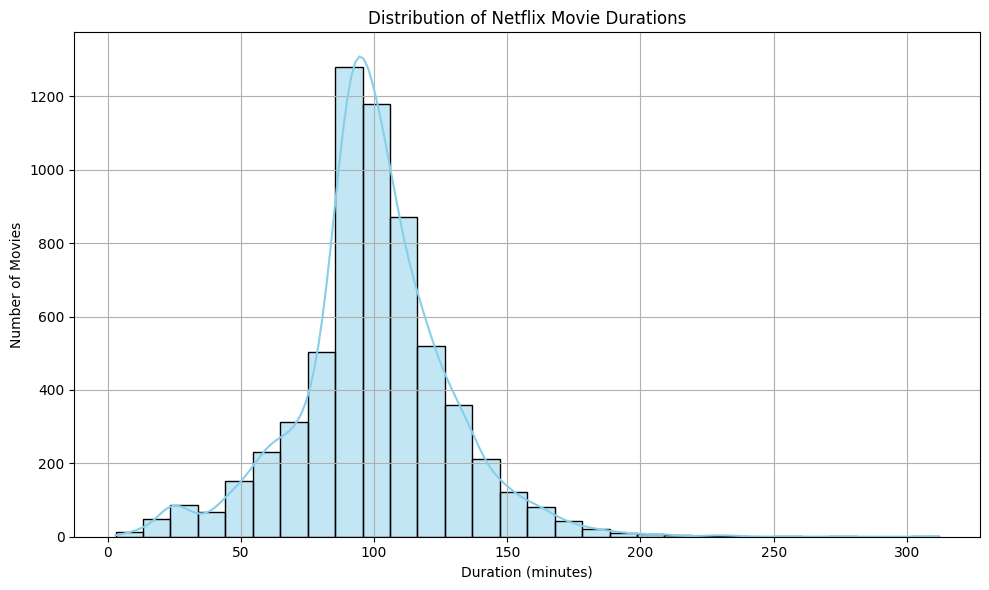

In [21]:
# Focus on movies only
movie_df = df[df['type'] == 'Movie']

# Drop rows without a valid duration
duration_data = movie_df['duration_minutes'].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(duration_data, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Netflix Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.tight_layout()


# Check basic stats
print("Mean:", duration_data.mean())
print("Median:", duration_data.median())
print("Max:", duration_data.max())
print("Min:", duration_data.min())


# Only consider Movies
movie_df = df[df['type'] == 'Movie']

# Drop missing durations
duration_data = movie_df['duration_minutes'].dropna()

# Calculate basic stats
mean_duration = duration_data.mean()
std_duration = duration_data.std()

# Define a threshold for "unusual" (e.g., outside mean ± 2 * std deviation)
lower_bound = mean_duration - 2 * std_duration
upper_bound = mean_duration + 2 * std_duration

# Find movies that are unusually short or long
unusual_movies = movie_df[
    (movie_df['duration_minutes'] < lower_bound) |
    (movie_df['duration_minutes'] > upper_bound)
][['title', 'duration_minutes']]

# Display results
print(f"📊 Average movie length: {mean_duration:.1f} minutes")
print(f"🧾 Unusually short: < {lower_bound:.1f} minutes")
print(f"🧾 Unusually long: > {upper_bound:.1f} minutes")
print("\n🎬 Movies with unusual durations:\n")
print(unusual_movies.sort_values('duration_minutes'))


plt.show()

🎥 5. Most frequent directors / actors

/tmp/ipython-input-4171438723.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values, y=top_actors.index, palette='magma')


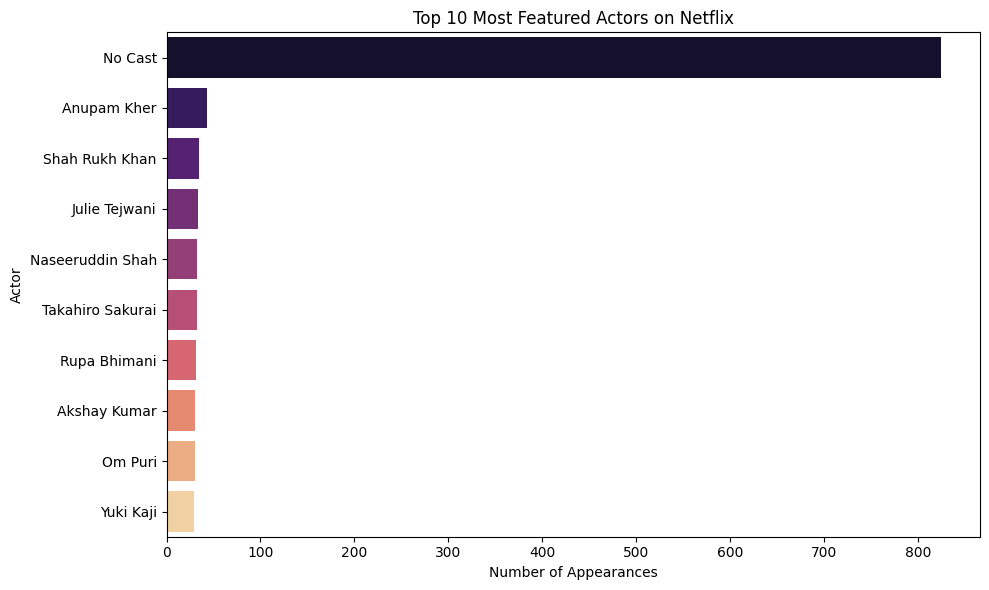

In [22]:
from collections import Counter

# Count actor appearances
actor_counter = Counter()

# Only use rows with valid cast info
df['cast'].dropna().str.split(', ').apply(actor_counter.update)

# Convert to Series and plot top 10
top_actors = pd.Series(actor_counter).sort_values(ascending=False).head(10)

# Count director appearances
director_counter = Counter()
df['director'].dropna().str.split(', ').apply(director_counter.update)

# Convert to Series and plot top 10
top_directors = pd.Series(director_counter).sort_values(ascending=False).head(10)


# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_actors.values, y=top_actors.index, palette='magma')
plt.title('Top 10 Most Featured Actors on Netflix')
plt.xlabel('Number of Appearances')
plt.ylabel('Actor')
plt.tight_layout()
plt.show()


📅 6. Which months or weekdays does Netflix add the most content?

/tmp/ipython-input-3103991946.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='cubehelix')


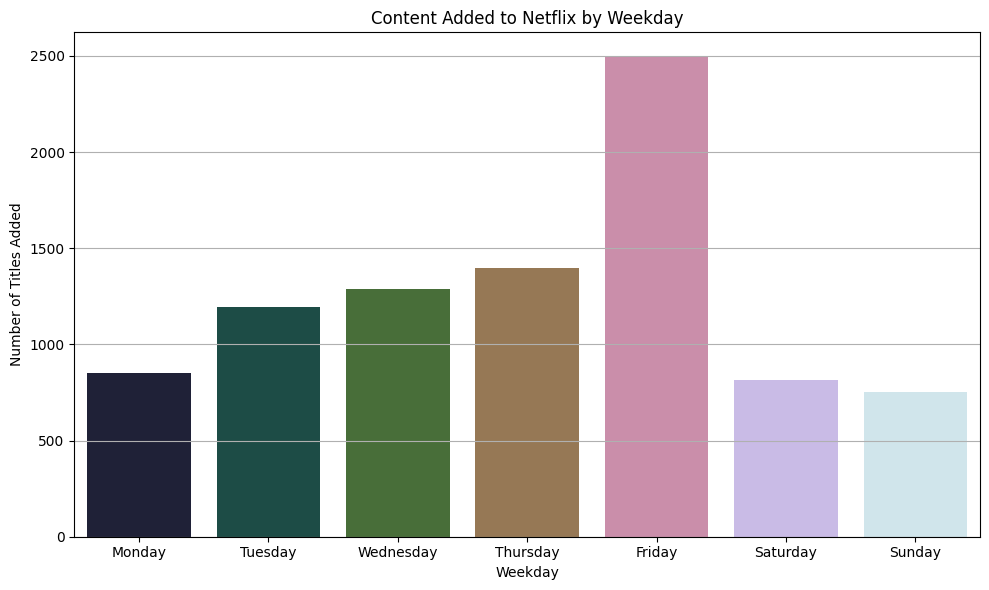

In [23]:
# Create a new column with the weekday name
df['weekday_added'] = df['date_added'].dt.day_name()

# Count titles added on each weekday
weekday_counts = df['weekday_added'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='cubehelix')
plt.title('Content Added to Netflix by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of Titles Added')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


7. Seasonal Content Additions (Month Analysis)

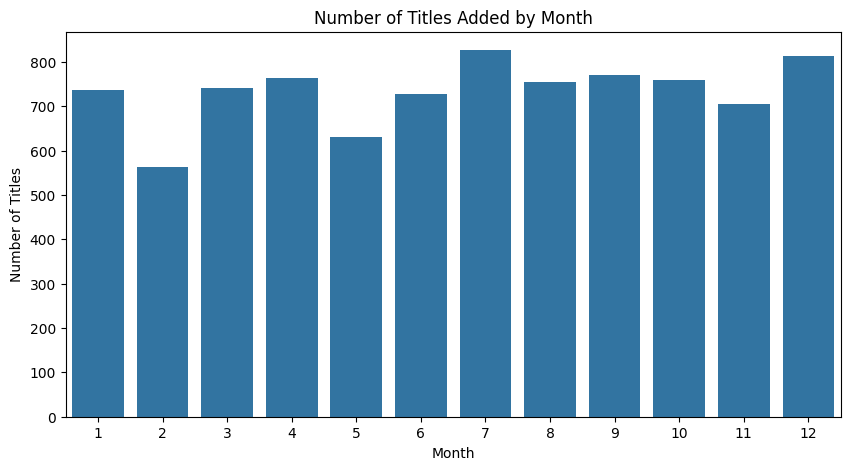

In [24]:
# Content added per month
month_counts = df['month_added'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=month_counts.index, y=month_counts.values)
plt.title('Number of Titles Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.show()


7. Age of Content When Added to Netflix

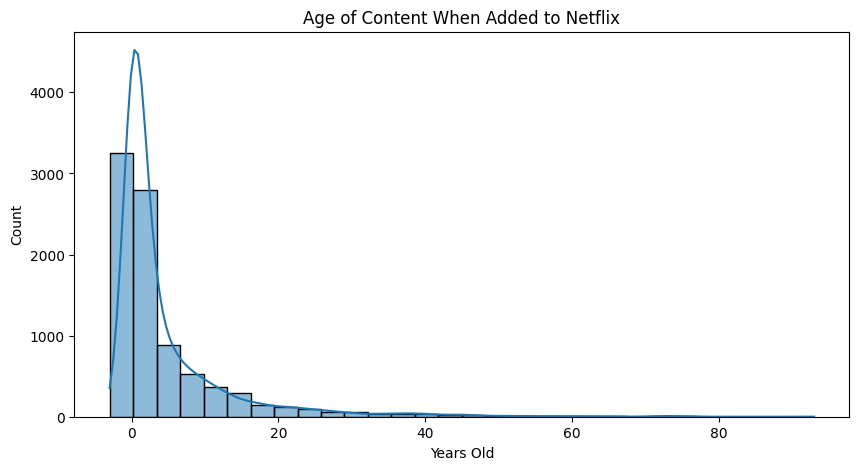

In [25]:
# How old content was when added
df['age_when_added'] = df['year_added'] - df['release_year']

plt.figure(figsize=(10, 5))
sns.histplot(df['age_when_added'], bins=30, kde=True)
plt.title('Age of Content When Added to Netflix')
plt.xlabel('Years Old')
plt.ylabel('Count')
plt.show()


8. Genre Trends Over Time (IMPORTANT)

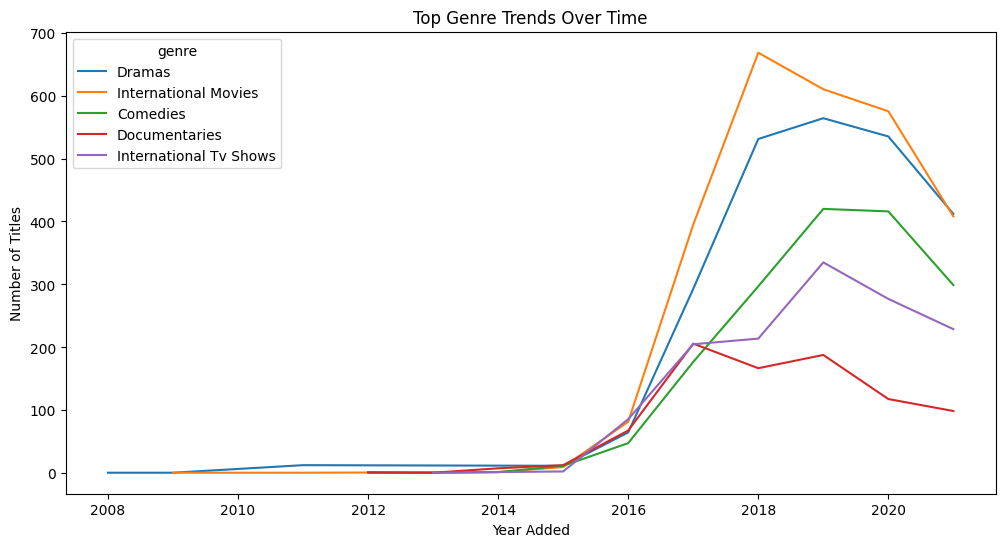

In [26]:
# Explode genres
genre_df = df[['year_added', 'listed_in']].dropna()
genre_df = genre_df.assign(
    genre=genre_df['listed_in'].str.split(', ')
).explode('genre')

# Count genre per year
genre_trend = genre_df.groupby(['year_added', 'genre']).size().reset_index(name='count')

# Top 5 genres overall
top_genres = genre_trend.groupby('genre')['count'].sum().sort_values(ascending=False).head(5).index

# Filter only top genres
genre_trend_top = genre_trend[genre_trend['genre'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=genre_trend_top, x='year_added', y='count', hue='genre')
plt.title('Top Genre Trends Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()


9. Country vs Content Type (Movie vs TV Show)

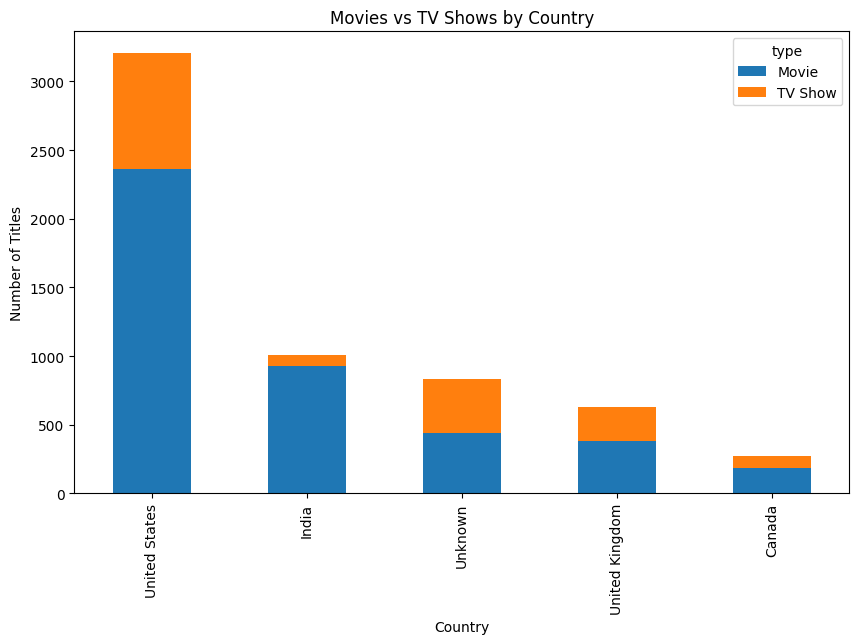

In [27]:
# Remove Unknown countries safely
country_type_df = df[df['main_country'].notna()]

country_type = (
    country_type_df
    .groupby(['main_country', 'type'])
    .size()
    .unstack()
    .fillna(0)
)

# Top 5 countries
top_countries = country_type.sum(axis=1).sort_values(ascending=False).head(5)
country_type.loc[top_countries.index].plot(
    kind='bar', stacked=True, figsize=(10, 6)
)

plt.title('Movies vs TV Shows by Country')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()


10. Multi-Country vs Single-Country Content

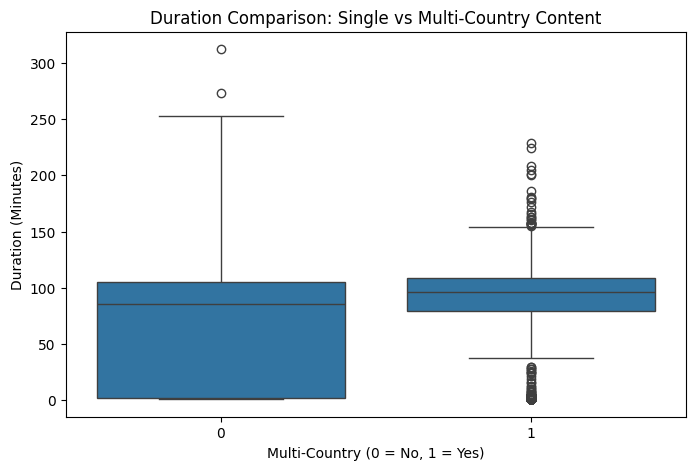

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='multi_country', y='duration_minutes', data=df)
plt.title('Duration Comparison: Single vs Multi-Country Content')
plt.xlabel('Multi-Country (0 = No, 1 = Yes)')
plt.ylabel('Duration (Minutes)')
plt.show()


11. Description Length Analysis (Text-Based)

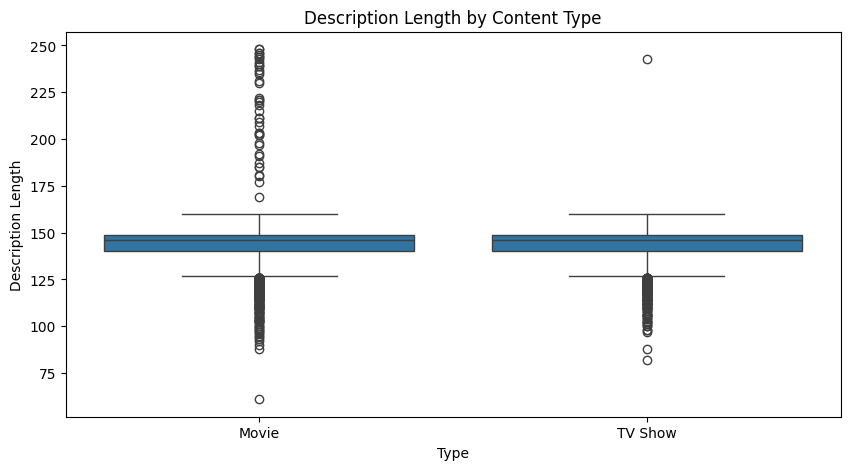

In [29]:
# Length of descriptions
df['description_length'] = df['description'].str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(x='type', y='description_length', data=df)
plt.title('Description Length by Content Type')
plt.xlabel('Type')
plt.ylabel('Description Length')
plt.show()


12. Feature Correlation (Light Statistics)


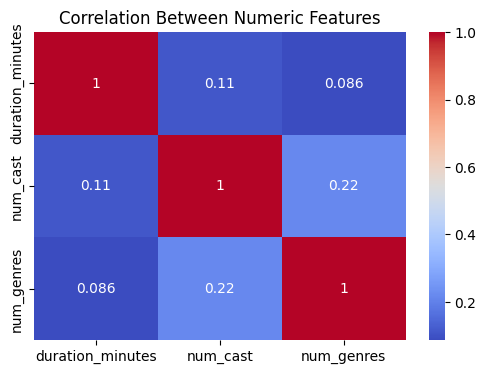

In [30]:
features = df[['duration_minutes', 'num_cast', 'num_genres']].dropna()

plt.figure(figsize=(6, 4))
sns.heatmap(features.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.show()


13. Outlier Content by Genre (Advanced Insight)

In [31]:
# Very long movies
long_movies = df[
    (df['type'] == 'Movie') &
    (df['duration_minutes'] > df['duration_minutes'].quantile(0.95))
]

long_movies[['title', 'duration_minutes', 'listed_in']].head(10)


,title,duration_minutes,listed_in
22,Avvai Shanmughi,161.0,"Comedies, International Movies"
24,Jeans,166.0,"Comedies, International Movies, Romantic Movies"
26,Minsara Kanavu,147.0,"Comedies, International Movies, Music & Musicals"
73,King Of Boys,182.0,"Dramas, International Movies"
78,Tughlaq Durbar,145.0,"Comedies, Dramas, International Movies"
79,Tughlaq Durbar (Telugu),145.0,"Comedies, Dramas, International Movies"
84,Omo Ghetto: The Saga,147.0,"Action & Adventure, Comedies, Dramas"
114,Anjaam,143.0,"Dramas, International Movies, Thrillers"
134,Clear And Present Danger,142.0,"Action & Adventure, Dramas"
136,Cold Mountain,154.0,"Dramas, Romantic Movies"


In [ ]:
# # Extract primary country
# df['main_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())

# # Optionally: label encoding for modeling
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df['main_country_encoded'] = le.fit_transform(df['main_country'])
